# ⚾ Data Mining & Analysis Final Project ⚾

### This mini-project explores the baseball strategy known as "pitching backwards" from a data-driven perspective.


Team: Banana Ball

Members: Gavin Gleinig, Sean Sayce

⚾🍌⚾🍌⚾🍌⚾🍌⚾🍌⚾🍌⚾🍌⚾🍌⚾🍌⚾




___
*Sidenote*: Why team name Banana Ball?


- "Banana Ball" (Coming to Kyle Field this May!) is famous for intentionally breaking the traditional rules and expectations of baseball to create a faster, more entertaining, and unpredictable game.
- In this notebook we too look at baseball strategy that is all about breaking conventions and defying expectations.
____

##  Background Info on 'Pitching Backwards'



### 1. The Traditional Definition

Traditonally "pitching backwards" means a pitcher throwing a **non-fastball** (e.g., curveball, changeup) in a **"fastball count."**

A "fastball count" (or hitters count) is any count where the batter has the advantage, typically when there are more balls than strikes and the at-bat isn't on the line with two strikes:
* 1-0
* 2-0
* 2-1
* 3-1
* 3-0 (arguably)
* 0-0 (arguably)


**Traditional Logic:**
1.  **Pitcher Needs a Strike:** In a hitter's count, the pitcher is behind and *must* throw a strike to avoid a walk.
2.  **Fastball = Control:** <u>For most pitchers</u>, the fastball is their most reliable and controllable pitch to throw for a strike.
3.  **Hitter Expects Fastball:** The batter knows this and prepares to hit a fastball.
4.  **The "Backwards" Pitch:** The pitcher defies this expectation by throwing an off-speed pitch, hoping to "steal" a strike or induce weak contact.

---

### 2. An Example

In this [clip from game 6 of the 2025 world series](https://youtube.com/clip/UgkxP3JLkN29yRu3SrSrpPN3Wd8F-TkZPR2A?si=6_dlTLPKej584fEW), the commentators note how Yoshinobu Yamamoto 'pitched backwards.' Interestingly, he actually threw a **fastball** on a 3-1 (fastball) count, and the announcers still called it "pitching backwards."

(Here is a more detailed [clip](https://youtube.com/clip/Ugkxo1NAOYSAdskc0SFN97MlZ_-TNBJEKwFB?si=6P8P4lNxkgSUeGHw) with an analyist breaking this scenario down)

The accouncers go on to explain that, for Yamamoto, a fastball is a "surprise." His overall fastball usage is low (e.g., ~20%). Ie, Batters step into the box *expecting* his offspeed.

So, on that 3-1 count, Barger was likely expecting an off-speed pitch. Yamamoto "defied expectations" by throwing his least-common pitch (the fastball) for a strike.

---

### 3. A More General Definition

So, in the later parts of this notebook, we'll expore a more general definition of pitching backwards. Namely,

> **"Pitching backwards" is when a pitcher defies *their own* established tendencies by throwing an unexpected, low-probability pitch in a given count.**

So, rather than a universal rule (like "no fastballs"), this strategy becomes <u>pitcher-specific</u> and <u> probabilistic</u>.


Ex)
* For a **traditional power pitcher** (e.g., 70% fastballs), a 2-0 **curveball** is pitching backwards. (think Nolan Ryan)
* For a **craftier pitcher like Yamamoto** (e.g., 25% fastballs), a 2-0 **fastball** is pitching backwards. (think Greg Maddux)
---
### 4. A Word of Warning

A brief look through online Forums and Articles has led us to believe that it is very difficult to determine why a particular pitch sequence works. Pitching sequencing is multifaced; it depends on velocity, movement, location, the hitter's expectations, and more. Game context (runners on base, inning, part of the lineup, etc) also plays a big role.

So, when working on this mini-project, we predict that separating the signal from the noise will be a key challenge.






# Q0: Basic Analysis / Verifying Assumptions

Answering Questions:
- Is there data to support that MLB pitchers really favor the fastball in fastball counts?
- Leaguewide, is a fastball or breaking ball more effective in a fastball count?
- Do relievers do more backwards pitching than starters?

### Downloading Data

In [ ]:
import warnings
import pandas as pd
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=pd.errors.DtypeWarning)

In [ ]:
!pip install pybaseball

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.7/432.7 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.1 MB/s eta 0:00:00


In [ ]:

import numpy as np
from pybaseball import statcast, playerid_reverse_lookup, pitching_stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [ ]:
from pybaseball import cache
cache.enable()

In [ ]:
print("Loading 2024 Statcast data")
# Load 2024 season data
league_data_2024 = statcast(start_dt='2024-03-20', end_dt='2024-10-31')
print(f"Loaded {len(league_data_2024)} total pitches.")

Loading 2024 Statcast data
This is a large query, it may take a moment to complete


100%|██████████| 226/226 [00:12<00:00, 18.71it/s]


Loaded 745349 total pitches.


In [ ]:
# # Print every attribute name on a new line
# for column in league_data_2024.columns:
#     print(column)

## Q0A: MLB pitchers really favor the fastball in fastball counts?


In [ ]:
#Looking at all of the different kinds of pitches
print(league_data_2024['pitch_type'].value_counts())

pitch_type
FF    235173
SI    115737
SL    111997
CH     74910
FC     60236
ST     49830
CU     46091
FS     22751
KC     13213
SV      3290
KN      1061
FA       632
EP       575
FO       186
SC       179
CS        61
PO        55
Name: count, dtype: int64


In [ ]:
# Look at the percentage of fastballs thrown in each kind of count
fastballs = (
    league_data_2024
    .dropna(subset=['pitch_type', 'balls', 'strikes'])
    .query('balls <= 3 and strikes <= 2')  # <-- filter out weird counts like 4-2
    .assign(
        is_fastball=lambda x: np.where(x['pitch_type'].isin(['FF', 'SI', 'FT', 'FC']), 1, 0),
        count=lambda x: x['balls'].astype(str) + '-' + x['strikes'].astype(str)
    )
)

final_table = (
    fastballs
    .groupby('count')['is_fastball']
    .mean()
    .sort_values(ascending=False)
    .apply('{:.1%}'.format)
)
print(final_table)


/tmp/ipython-input-2644791597.py:5: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query('balls <= 3 and strikes <= 2')  # <-- filter out weird counts like 4-2


count
3-0    94.8%
3-1    77.9%
2-0    70.8%
3-2    63.1%
0-0    61.0%
1-0    59.7%
2-1    59.0%
1-1    51.2%
0-1    51.0%
2-2    49.3%
1-2    44.9%
0-2    44.5%
Name: is_fastball, dtype: object


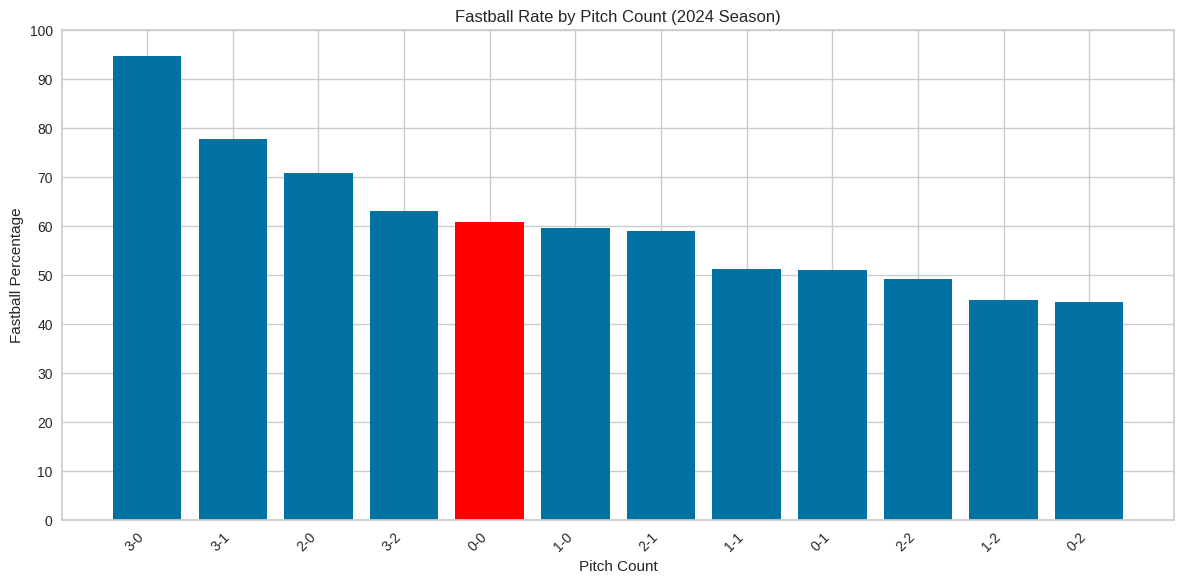

In [ ]:
fastball_rates = (
    fastballs
    .groupby('count')['is_fastball']
    .mean()
    .sort_values(ascending=False)
)

# Drop impossible counts if needed
fastball_rates = fastball_rates[~fastball_rates.index.isin(['4-2'])]

# Color 0-0 red, everything else default blue
colors = ['red' if c == '0-0' else 'C0' for c in fastball_rates.index]

plt.figure(figsize=(12, 6))
plt.bar(fastball_rates.index, fastball_rates.values * 100, color=colors)

plt.xlabel("Pitch Count")
plt.ylabel("Fastball Percentage")
plt.title("Fastball Rate by Pitch Count (2024 Season)")

plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)                         # 0–100%
plt.yticks(np.arange(0, 101, 10))        # ✅ ticks every 10%

plt.tight_layout()
plt.show()


## Creating Pitch Groups and Count Groups
In this statcast data, pitches are classified into more granular types than fastball vs breaking ball.

We want to look at the differences between fastballs and breaking balls. While more advances differences could be analyized (looking at tunneling of types of fastballs, pitch mirroring, etc), we are only looking at the broad strokes.

In [ ]:
def classify_pitch_group(df):
    """Classifies pitches into broader groups (breaking ball, curveball, offspeed)"""
    # Ensure 'pitch_type' column exists
    if 'pitch_type' not in df.columns:
        return pd.Series(index=df.index, dtype='object')

    # Create a mapping from Statcast codes to our groups
    # CU=Curveball, SL=Slider, KC=Knuckle Curve, ST = Sweeper, SV = slurve,
    breaking_ball_types = ['CU', 'SL', 'KC', 'ST', 'SV']
    # FF=4-Seam, SI=Sinker, FT=2-Seam, FC = cutter, FA= generic fastball
    fastball_types = ['FF', 'SI', 'FT', 'FC', 'FA']
    # CH=Changeup, FS=Splitter, FO=forkball, SC=screwball
    offspeed_types = ['CH', 'FS', 'FO', 'SC']

    def assign_group(pt):
        if pt in breaking_ball_types:
            return 'Breaking'
        elif pt in fastball_types:
            return 'Fastball'
        elif pt in offspeed_types:
            return 'Offspeed'
        else:
            return 'Other' #knuckleball, eephus,

    return df['pitch_type'].apply(assign_group)

In [ ]:
def classify_count_group(df):
    """Classifies counts into 'Behind', 'Ahead', or 'Even'."""
    # 'Behind' (Hitter's count)
    behind_counts = [
        (1, 0), (2, 0), (2, 1), (3, 1), (3, 0) #,(0,0)
    ]
    # 'Ahead' (Pitcher's count)
    ahead_counts = [
        (0, 1), (0, 2), (1, 2), (2, 2)
    ]

    def assign_group(row):
        count = (row['balls'], row['strikes'])
        if count in behind_counts:
            return 'Behind'
        elif count in ahead_counts:
            return 'Ahead'
        else:
            return 'Even'

    return df.apply(assign_group, axis=1)

In [ ]:
league_data_2024['pitch_group'] = classify_pitch_group(league_data_2024)
league_data_2024['count_group'] = classify_count_group(league_data_2024)

Ok, overall, lets see if breakings balls are thrown more often when behind or ahead in the count.

Following common thinking, more breaking balls (tricky pitches) should be thrown when the pitcher is ahead in the count.

In [ ]:
league_relevant = league_data_2024[league_data_2024['count_group'].isin(['Behind', 'Ahead'])]

league_bb_pct = league_relevant[
    league_relevant['pitch_group'] == 'Breaking'
].groupby('count_group').size() / league_relevant.groupby('count_group').size()

print("League-wide Breaking Ball % (2024 Season):")
print(league_bb_pct * 100)

League-wide Breaking Ball % (2024 Season):
count_group
Ahead     34.969163
Behind    22.619176
dtype: float64


So working off the above obervation, yes, Pitchers do tend to lean away from throwing breaking balls when behind in the count; ie, they throw fastballs instead.

Lets now look at the differences in results when throwing different pitches in fsatball counts.

## Q0B: Is a fastball or breaking ball more effective in a fastball count?


In [ ]:
hitter_count_data = league_data_2024[league_data_2024['count_group'].isin(['Behind'])].copy()

In [ ]:
def calculate_pitch_outcomes(group):
    """Helper function to calculate metrics for a pitch group."""
    total_pitches = len(group)
    if total_pitches == 0:
        return pd.Series(dtype='float64')

    metrics = {}
    metrics['Total Pitches'] = total_pitches

    # Calculate percentages
    metrics['Whiff %'] = (group['description'].isin(['swinging_strike', 'foul_tip']).sum() / total_pitches)
    metrics['Called Strike %'] = (group['description'] == 'called_strike').sum() / total_pitches
    metrics['Ball %'] = (group['description'] == 'ball').sum() / total_pitches
    metrics['In Play %'] = (group['type'] == 'X').sum() / total_pitches

    # Calculate wOBA on Batted Balls (damage)
    bip_group = group[group['type'] == 'X']
    # woba_value is the league-avg wOBA for that event type (e.g., 'single', 'home_run')
    metrics['wOBA on Contact'] = bip_group['woba_value'].mean()

    return pd.Series(metrics)

# Group by our two categories and apply the metric calculation
analysis = hitter_count_data.groupby('pitch_group').apply(calculate_pitch_outcomes)

/tmp/ipython-input-437683603.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analysis = hitter_count_data.groupby('pitch_group').apply(calculate_pitch_outcomes)


In [ ]:
formatters = {
    'Total Pitches': '{:,.0f}'.format,
    'Whiff %': '{:.1%}'.format,
    'Called Strike %': '{:.1%}'.format,
    'Ball %': '{:.1%}'.format,
    'In Play %': '{:.1%}'.format,
    'wOBA on Contact': '{:.3f}'.format
}

print("\n--- Results: Pitch Effectiveness in 'Fastball Counts' ---")
print(analysis.to_string(formatters=formatters))


--- Results: Pitch Effectiveness in 'Fastball Counts' ---
            Total Pitches Whiff % Called Strike % Ball % In Play % wOBA on Contact
pitch_group                                                                       
Breaking           35,582   14.5%           24.2%  29.7%     13.9%           0.404
Fastball          100,128    8.6%           23.0%  29.2%     18.9%           0.404
Offspeed           18,558   16.8%           15.1%  32.6%     16.6%           0.379
Other               3,041    2.6%            4.4%  33.0%      6.6%           0.530


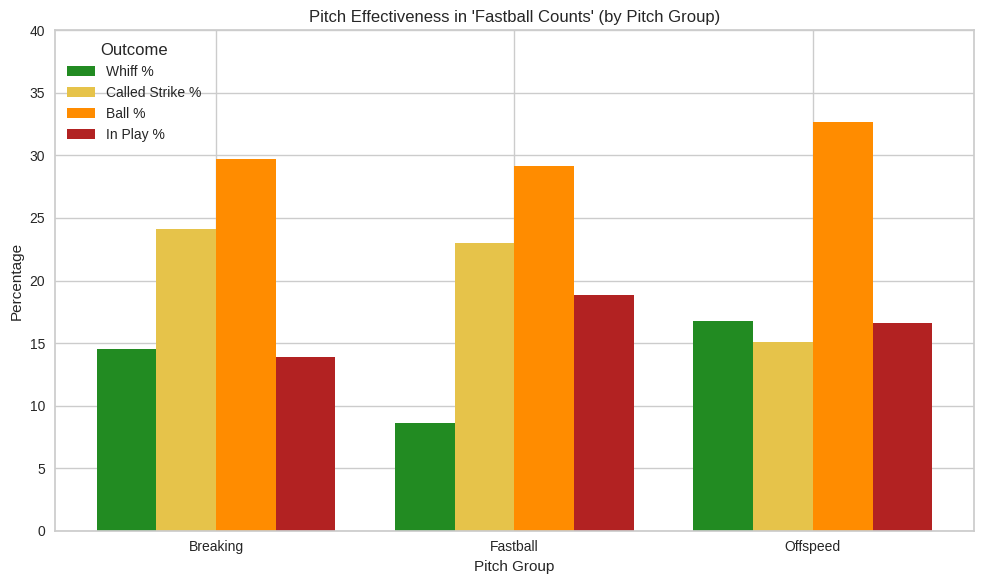

In [ ]:
# Keep only Fastball / Breaking / Offspeed
clean_analysis = analysis.drop(index='Other', errors='ignore')

metrics = ['Whiff %', 'Called Strike %', 'Ball %', 'In Play %']
colors = [
    '#228B22',  # lighter dark green (forest green)
    '#E6C34A',  # lighter dark yellow (goldenrod)
    '#FF8C00',  # dark orange (unchanged)
    '#B22222'   # lighter dark red (firebrick)
]


groups = clean_analysis.index
x = np.arange(len(groups))
width = 0.20

plt.figure(figsize=(10, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar(x + i * width, clean_analysis[metric] * 100, width,
            label=metric, color=color)

plt.xlabel("Pitch Group")
plt.ylabel("Percentage")
plt.title("Pitch Effectiveness in 'Fastball Counts' (by Pitch Group)")
plt.xticks(x + width * 1.5, groups)
plt.ylim(0, 40)
plt.yticks(np.arange(0, 41, 5))
plt.legend(title="Outcome")

plt.tight_layout()
plt.show()


So yes; from these basic stats, throwing a breaking pitch in a fastball count is a highly effective strategy!

This is because:

Breaking balls have a larger whiff rate, a smaller in play rate, and very similar ball% rate.

Interestingly, the Ball% of breaking balls vs fastballs is almost identical. This refutes the youth-league trusim that fastballs are easier to throw for a strike. It appears that, at the MLB level in 2024, in aggregate, pitchers could locate their breaking balls for a strike just as effectively as their fastballs.


___
Instead of just looking at just wOBA on contact (only looks at balls put in play), what if we assign a score to every pitch outcome?

Very smart people have calculated the expected amount of runs gained from every pitch outcome, be it single, foul ball, home run, etc. I'll use the 2024 version of these values.





In [ ]:
# ----------------------------------------------------------------------------------
# 1. Define Linear Weights (Run Values)
# Updated for 2024 MLB Season
# Derived from FanGraphs 'Guts' Table 2024
# ----------------------------------------------------------------------------------
RUN_VALUES = {
    # Pitch Outcomes (Approximate 2024 Baselines)
    # These fluctuate less than hit values but slightly favor pitchers in 2024
    'ball': 0.06,
    'blocked_ball': 0.06,
    'called_strike': -0.06,
    'swinging_strike': -0.11, # Whiff rates were slightly up, value slightly higher
    'foul': -0.04,
    'foul_tip': -0.11,
    'hit_by_pitch': 0.31,      # Slightly down from baseline (0.33)

    # Batted Ball Outcomes (Events) - Calculated from 2024 wOBA Constants
    'single': 0.44,
    'double': 0.74,
    'triple': 1.01,
    'home_run': 1.38,
    'walk': 0.29,

    # Outs
    'strikeout': -0.27,        # Standard run cost of an out
    'field_out': -0.27,
    'force_out': -0.27,
    'grounded_into_double_play': -0.35, # Remains high cost
    'sac_fly': -0.03,          # Sac flies were slightly less valuable relative to outs
}

def assign_run_value(row):
    """
    Assigns a run value to a pitch based on its 'events' (result of PA)
    or its 'description' (result of pitch if PA didn't end).
    """
    # 1. Check for a defining event (e.g., Single, Home Run, Strikeout)
    # 'events' column in Statcast usually holds the PA result
    event = row.get('events')

    if pd.notna(event) and event in RUN_VALUES:
        return RUN_VALUES[event]

    # 2. If no PA-ending event, check the pitch description (Ball, Strike, Foul)
    desc = row.get('description')

    # Special handling for 2-strike fouls (often worth 0 run value in simple models
    # because the count doesn't change, though strictly speaking it wastes a pitch)
    if desc == 'foul' and row.get('strikes') == 2:
        return 0.0

    if desc in RUN_VALUES:
        return RUN_VALUES[desc]

    # Default neutral value if unknown
    return 0.0


In [ ]:
def analyze_run_values(df):
    # Apply the run value calculation row-by-row
    df['run_value'] = df.apply(assign_run_value, axis=1)

    # Helper to aggregate metrics
    def aggregate_rv(group):
        total_pitches = len(group)
        total_rv = group['run_value'].sum()

        return pd.Series({
            'Total Pitches': total_pitches,
            'Total Run Value': total_rv,
            # RV/100 is the standard metric.
            # Lower (more negative) is BETTER for the pitcher.
            'RV per 100': (total_rv / total_pitches) * 100,
            # We can also look at damage specifically on contact
            'Batted Ball RV': group[group['type'] == 'X']['run_value'].sum()
        })

    # Group by your pitch groups (Fastball vs Breaking vs Offspeed)
    results = df.groupby('pitch_group').apply(aggregate_rv)

    # Sorting by RV per 100 (ascending) to see which is most effective for the pitcher
    return results.sort_values('RV per 100')


In [ ]:
rv_analysis = analyze_run_values(hitter_count_data)

# Formatting for pretty printing
formatters = {
    'Total Pitches': '{:,.0f}'.format,
    'Total Run Value': '{:,.1f}'.format,
    'RV per 100': '{:.2f}'.format,
    'Batted Ball RV': '{:,.1f}'.format
}

print("\n--- Linear Weights / Run Value Analysis in Fastball Counts ---")
print("Note: Lower 'RV per 100' is better for the pitcher (prevents runs).")
print(rv_analysis.to_string(formatters=formatters))


--- Linear Weights / Run Value Analysis in Fastball Counts ---
Note: Lower 'RV per 100' is better for the pitcher (prevents runs).
            Total Pitches Total Run Value RV per 100 Batted Ball RV
pitch_group                                                        
Breaking           35,582          -143.4      -0.40          263.4
Offspeed           18,558           -20.5      -0.11           96.6
Fastball          100,128           942.6       0.94          981.0
Other               3,041           141.5       4.65           32.4


/tmp/ipython-input-3753983216.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = df.groupby('pitch_group').apply(aggregate_rv)


So this analysis also shows that pitchign backwards is more effective. Ie, per 100 pitches, pitching backwards actually reduces runs scored by 0.4. Where as, by throwing a fastball, 0.94 more runs are scored by the team. This is a difference of 2.08 runs per 100 pitches!

In [ ]:
# 1. Filter data for 'Ahead' counts using your pre-defined count_group
# Note: Ensure 'league_data_2024' has the 'count_group' column from Q0
ahead_count_data = league_data_2024[league_data_2024['count_group'] == 'Ahead'].copy()

# 2. Apply the Run Value analysis using your existing function
rv_analysis_ahead = analyze_run_values(ahead_count_data)

# 3. Formatting for pretty printing (same format as before)
formatters = {
    'Total Pitches': '{:,.0f}'.format,
    'Total Run Value': '{:,.1f}'.format,
    'RV per 100': '{:.2f}'.format,
    'Batted Ball RV': '{:,.1f}'.format
}

print("\n--- Linear Weights / Run Value Analysis in Pitcher's Counts (Ahead) ---")
print("Note: Lower 'RV per 100' is better for the pitcher (prevents runs).")
print(rv_analysis_ahead.to_string(formatters=formatters))


--- Linear Weights / Run Value Analysis in Pitcher's Counts (Ahead) ---
Note: Lower 'RV per 100' is better for the pitcher (prevents runs).
            Total Pitches Total Run Value RV per 100 Batted Ball RV
pitch_group                                                        
Other               3,055          -211.5      -6.92           63.9
Breaking           99,111        -1,992.8      -2.01          189.3
Offspeed           46,579          -841.2      -1.81         -121.2
Fastball          134,679        -2,082.9      -1.55          456.2


/tmp/ipython-input-3753983216.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = df.groupby('pitch_group').apply(aggregate_rv)


Interestingly, even in "Ahead" counts, the breakings ball still outperforms the fastball. (But now only a 0.39 difference).

I take this to mean that, these breaking pitches lead to better outcomes. But even though breaking balls give superior outcomes, oddly, still, in these counts, fastballs are still thrown more often than breaking balls.

But, as with two competing players, if the batter is expecting a breaking ball, this advantage would likely go down. The speed and potential of a good fastball improves the breaking ball.

## Downloading Advanced Metrics

This data includes season-wide ratings on each pitcher. Includes data like Stuff+, Location+, WAR, etc.

These metrics allow for quick, easy to reference numbers that describe the charactertics and effectiveness of a pitcher.

In [ ]:
# --- REVISED Data Processing Block ---
# 1. Load FanGraphs Advanced Metrics
print("Loading 2024 FanGraphs Pitching Data...")
fg_data = pitching_stats(2024, qual=30)
fg_cols = ['IDfg', 'Name', 'Team', 'WAR', 'ERA', 'Stuff+', 'Location+']
fg_data = fg_data[[c for c in fg_cols if c in fg_data.columns]]

# 2. Calculate Strategic Features from Statcast
print("Calculating Pitcher Strategies...")
df = league_data_2024.copy()
df['is_fastball'] = df['pitch_group'] == 'Fastball'
df['is_hitter_count'] = df['count_group'] == 'Behind'

overall_stats = df.groupby('pitcher').agg(
    total_pitches=('pitch_type', 'count'),
    fb_pct_overall=('is_fastball', 'mean')
)
hitter_count_stats = df[df['is_hitter_count']].groupby('pitcher')['is_fastball'].mean().rename('fb_pct_hitter_count')

pitcher_strategy = overall_stats.join(hitter_count_stats)
pitcher_strategy['backwards_diff'] = pitcher_strategy['fb_pct_hitter_count'] - pitcher_strategy['fb_pct_overall']

# 3. Filter and Merge
MIN_PITCHES = 500
qualified_pitchers = pitcher_strategy[pitcher_strategy['total_pitches'] >= MIN_PITCHES].reset_index()

# Map IDs
player_map = playerid_reverse_lookup(qualified_pitchers['pitcher'].values, key_type='mlbam')
player_map = player_map[['key_mlbam', 'key_fangraphs']].dropna()

# Final Merge
final_pitcher_data = (
    qualified_pitchers
    .merge(player_map, left_on='pitcher', right_on='key_mlbam')
    .merge(fg_data, left_on='key_fangraphs', right_on='IDfg')
)

# NOTE: We keep 'key_mlbam' this time so we can merge with entropy data later
print(f"Qualified Pitchers: {len(final_pitcher_data)}")

Loading 2024 FanGraphs Pitching Data...
Calculating Pitcher Strategies...
Gathering player lookup table. This may take a moment.
Qualified Pitchers: 431


## Q0C: Do Relief pitchers or starters do more backwards pitching?

Note that I'm taking this code from Q3, pasting here and using quickly for this question

In [ ]:
from scipy.stats import entropy

# Ensure Count and Pitch Groups exist (Consistency with Q0)
if 'count' not in league_data_2024.columns:
    #Here, want to do more granular counts than the above count_group category
    league_data_2024['count'] = league_data_2024['balls'].astype(str) + '-' + league_data_2024['strikes'].astype(str)
if 'pitch_group' not in league_data_2024.columns:
    league_data_2024['pitch_group'] = classify_pitch_group(league_data_2024)

# Filter dataset to ONLY include the qualified pitchers identified in Q1
qualified_ids = playerid_reverse_lookup(final_pitcher_data['IDfg'].values, key_type='fangraphs')['key_mlbam'].values
q2_data = league_data_2024[league_data_2024['pitcher'].isin(qualified_ids)]

hitter_counts = ['1-0','2-0','2-1','3-1','3-0','3-2']
 #            ['2-0', '3-1'] #3-0? # Deep hitter counts (High pressure to throw strikes)



pitcher_counts = ["0-1",'1-1','0-2','1-2','2-2']
 #['0-2', '1-2']       # Deep pitcher counts (High freedom to sequence)
hitter_data = league_data_2024[league_data_2024['count'].isin(hitter_counts)].copy()
pitcher_data = league_data_2024[league_data_2024['count'].isin(pitcher_counts)].copy()

def calculate_shannon_entropy(series):
    # Filter out small samples to avoid noise
    if len(series) < 15:
        return np.nan

    value_counts = series.value_counts(normalize=True, sort=False)
    return entropy(value_counts, base=2)

entropy_behind = hitter_data.groupby('pitcher')['pitch_group'].apply(calculate_shannon_entropy).rename('entropy_behind')
entropy_ahead = pitcher_data.groupby('pitcher')['pitch_group'].apply(calculate_shannon_entropy).rename('entropy_ahead')

# 2. Combine and Compare
comparison_df = pd.concat([entropy_behind, entropy_ahead], axis=1).dropna()

# 3. The "conformity_index"
# If index is POSITIVE, they are more predictable when they fall behind
# If index is NEAR ZERO, they pitch the same regardless of count (Stubborn/Stable).
# If index is NEGATIVE, they become more random when they fall behind
comparison_df['conformity_index'] = comparison_df['entropy_ahead'] - comparison_df['entropy_behind']


Fetching 2024 pitching roles...


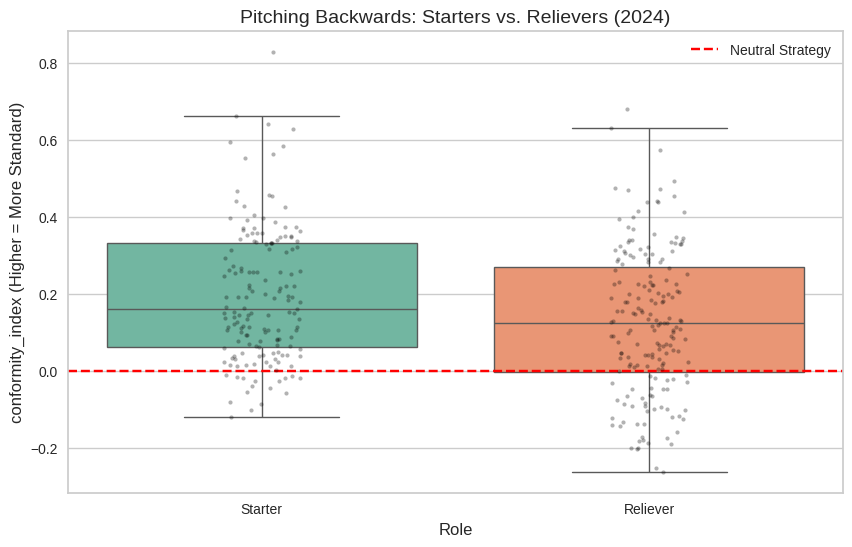

In [ ]:
# 1. Fetch Role Data (Games vs. Starts)
print("Fetching 2024 pitching roles...")
# qual=1 ensures we get relievers too
role_data = pitching_stats(2024, qual=1)[['IDfg', 'Name', 'G', 'GS']]

# 2. Merge with your existing Entropy Data
# We use 'final_pitcher_data' to map IDs, then merge with comparison_df
# Ensure comparison_df has 'key_mlbam' as a column
if 'key_mlbam' not in comparison_df.columns:
    comparison_df = comparison_df.reset_index().rename(columns={'pitcher': 'key_mlbam'})

# Create a master dataframe with Roles and Predictability
analysis_df = comparison_df.merge(
    final_pitcher_data[['key_mlbam', 'key_fangraphs']],
    on='key_mlbam'
).merge(
    role_data,
    left_on='key_fangraphs',
    right_on='IDfg'
)

# 3. Define Roles
def classify_role(row):
    if row['GS'] == 0:
        return 'Reliever'
    elif row['GS'] / row['G'] > 0.8:
        return 'Starter'
    else:
        return 'Hybrid/Opener'

analysis_df['Role'] = analysis_df.apply(classify_role, axis=1)

# Filter for pure Starters and Relievers
plot_data = analysis_df[analysis_df['Role'].isin(['Starter', 'Reliever'])]

# 4. Visualizing the Gap
plt.figure(figsize=(10, 6))
sns.boxplot(x='Role', y='conformity_index', data=plot_data, palette="Set2", showfliers=False)
sns.stripplot(x='Role', y='conformity_index', data=plot_data, color='black', alpha=0.3, size=3)

plt.axhline(0, color='red', linestyle='--', label='Neutral Strategy')
plt.title("Pitching Backwards: Starters vs. Relievers (2024)", fontsize=14)
plt.ylabel("conformity_index (Higher = More Standard)", fontsize=12)
plt.xlabel("Role", fontsize=12)
plt.legend()
plt.show()


Yes, starters are significantly more lifely to traditional pitchers; relief does more backwards pitching.

Relievers can expend maximum effort on every pitch without worrying about longevity.

# Q1: Finding Pitcher Archetypes

## Are there two groups of pitchers, backwards and forwards?

Above, we've noted that there are perhaps two different archetypes of pitchers.

We want to explore if this is really the case and, if it is true, the difference between groups.

In [ ]:
# Define the final list of features for the model
cluster_features = [
    'backwards_diff', # Strategic choice
    # 'HardHit%',       # Quality of Contact (Stuff/Location)
    # 'CSW%',           # Stuff + Location
    # 'Zone%',           # Location
    'Stuff+',
    'Location+'
]

# Create the feature matrix X, dropping any rows with missing data
X = final_pitcher_data[cluster_features].dropna()

# Create a separate DataFrame for plotting/analysis that matches the rows in X
# (This keeps 'Name' and 'Team' aligned with the clusters)
plot_data = final_pitcher_data.loc[X.index].copy()

# 2. Scale the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 3. Run KMeans Clustering
# We use k=2 as determined previously
chosen_k = 2
kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
plot_data['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Interpret the Results
print("\nCluster Summary (Means):")
cluster_summary = plot_data.groupby('cluster')[cluster_features].mean()
print(cluster_summary)

# Optional: View top pitchers in each cluster
print("\nTop 3 Pitchers in Cluster 0 (by WAR):")
print(plot_data[plot_data['cluster']==0].sort_values('WAR', ascending=False)[['Name', 'Team', 'backwards_diff']].head(3))

print("\nTop 3 Pitchers in Cluster 1 (by WAR):")
print(plot_data[plot_data['cluster']==1].sort_values('WAR', ascending=False)[['Name', 'Team', 'backwards_diff']].head(3))


Cluster Summary (Means):
         backwards_diff      Stuff+   Location+
cluster                                        
0              0.122308  106.068063   95.623037
1              0.057354   97.454167  103.208333

Top 3 Pitchers in Cluster 0 (by WAR):
             Name Team  backwards_diff
318  Tarik Skubal  DET        0.079022
46   Zack Wheeler  PHI        0.096492
288   Cole Ragans  KCR        0.103490

Top 3 Pitchers in Cluster 1 (by WAR):
            Name Team  backwards_diff
26    Chris Sale  ATL        0.044499
119    Seth Lugo  KCR        0.091337
205  Dylan Cease  SDP        0.067176



Visualizing clusters...


/tmp/ipython-input-3551866360.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  labeled_pitchers = plot_data.groupby('cluster').apply(


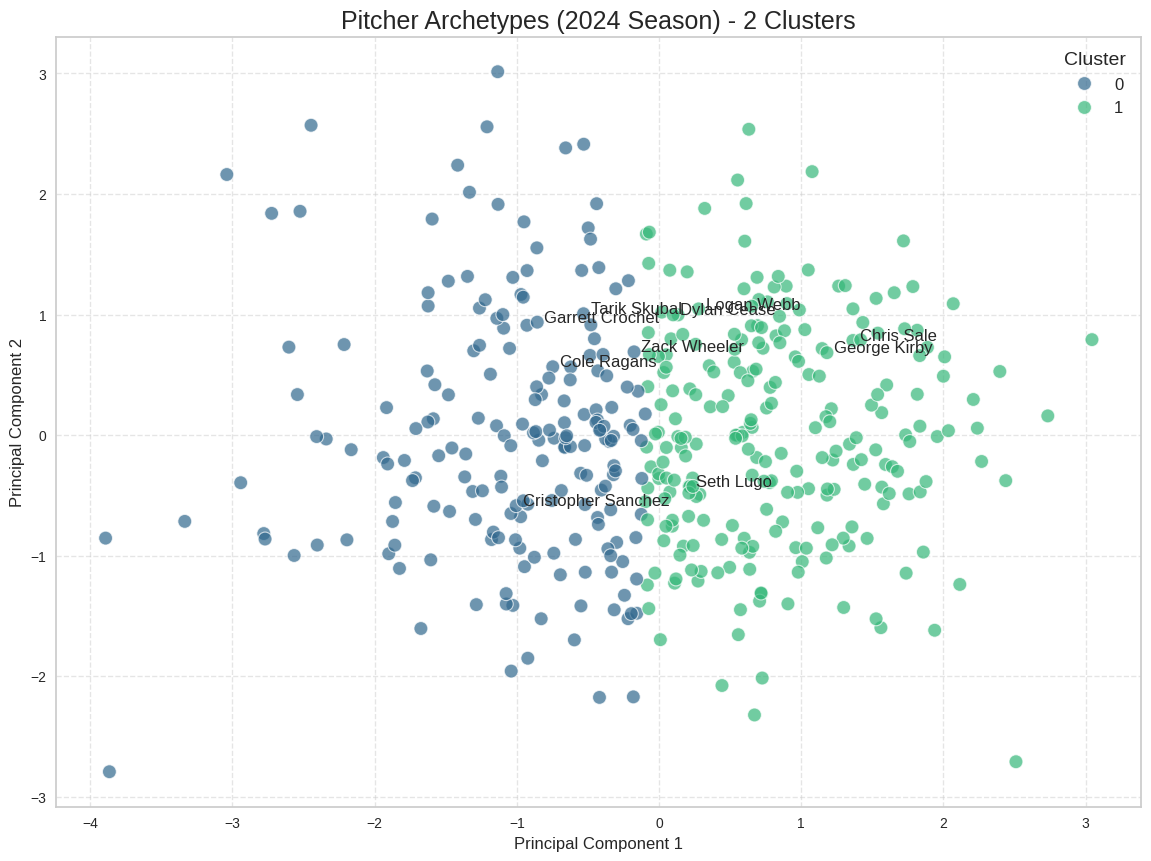

In [ ]:

print("\nVisualizing clusters...")

# Use PCA to reduce the data to 2 components for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Add PCA components to our DataFrame
plot_data['pca1'] = X_pca[:, 0]
plot_data['pca2'] = X_pca[:, 1]

# Create the scatter plot
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=plot_data,
    x='pca1',
    y='pca2',
    hue='cluster',
    palette='viridis',
    s=100,
    alpha=0.7
)

# Add labels for a few pitchers (e.g., top 5 by WAR in each cluster)
labeled_pitchers = plot_data.groupby('cluster').apply(
    lambda x: x.nlargest(5, 'WAR')
).reset_index(drop=True)

for i, row in labeled_pitchers.iterrows():
    plt.text(row['pca1'] + 0.05, row['pca2'], row['Name'])

plt.title(f'Pitcher Archetypes (2024 Season) - {chosen_k} Clusters', fontsize=18)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster', fontsize=12, title_fontsize=14, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

With visual analysis of the above visualization, it looks like there isn't a good separation between backwards and normal pitchers.

Note that this notebook doesn't contain all of our attempts; we've tried to cluster on many different kinds of features and engineering features using different numbers of clusters. All resulted in fairly poor clustering; when visualzed, the above 'blob' formed.

We belive this poor result is likely because sequencing is more of a fluid strategy rather than a fixed trait. (Each at-bat is a new situation)

This makes sense, at least from a game-theory perspective. If a pitcher was known to be a backwards pitcher or normal pitcher, the hitter could expect it. Taking ideas form game theory, instead, pitchers tend to find a "nash equilibrium" of sorts, where pitchers must constantly adjust their approach to avoid becoming predictable and giving an edge to the batter.

# Q2: Do pitchers have higher predictability when behind in the count (e.g., 2-0, 3-1) compared to ahead in the count (0-2, 1-2)?

So, we were not able to cluster pitchers by their overall tendency on throwing fastballs vs breaking balls.

But above, we noted that Yamamoto's kind of backwards pitching occured when he threw a fastball in a fastball count.

Instead, we want to look at how a pitcher's predictability changes based on the count. So, in essense, are some pitchers more unpredictable than others when they fall behind? In other words:
- Are some pitchers more predictable when backed into a corner?
- Are these pitchers more or less effective by doing this?
- Are there some pitchers that could perhaps improve by

There is an article on Baseball Prospectus that finds the same;  pitchers are not perfectly random; overall **they get more predictable when they get further behind in the count**.

First, we want to verify that with 2024 data.

## Q2A: Are some pitchers significanctly more/less predictable when ahead versus behind in the count?

In [ ]:
from scipy.stats import entropy

# Ensure Count and Pitch Groups exist (Consistency with Q0)
if 'count' not in league_data_2024.columns:
    #Here, want to do more granular counts than the above count_group category
    league_data_2024['count'] = league_data_2024['balls'].astype(str) + '-' + league_data_2024['strikes'].astype(str)
if 'pitch_group' not in league_data_2024.columns:
    league_data_2024['pitch_group'] = classify_pitch_group(league_data_2024)

# Filter dataset to ONLY include the qualified pitchers identified in Q1
qualified_ids = playerid_reverse_lookup(final_pitcher_data['IDfg'].values, key_type='fangraphs')['key_mlbam'].values
q2_data = league_data_2024[league_data_2024['pitcher'].isin(qualified_ids)]

hitter_counts = ['1-0','2-0','2-1','3-1','3-0','3-2']
 #            ['2-0', '3-1'] #3-0? # Deep hitter counts (High pressure to throw strikes)



pitcher_counts = ["0-1",'1-1','0-2','1-2','2-2']
 #['0-2', '1-2']       # Deep pitcher counts (High freedom to sequence)
hitter_data = league_data_2024[league_data_2024['count'].isin(hitter_counts)].copy()
pitcher_data = league_data_2024[league_data_2024['count'].isin(pitcher_counts)].copy()

def calculate_shannon_entropy(series):
    # Filter out small samples to avoid noise
    if len(series) < 15:
        return np.nan

    value_counts = series.value_counts(normalize=True, sort=False)
    return entropy(value_counts, base=2)

entropy_behind = hitter_data.groupby('pitcher')['pitch_group'].apply(calculate_shannon_entropy).rename('entropy_behind')
entropy_ahead = pitcher_data.groupby('pitcher')['pitch_group'].apply(calculate_shannon_entropy).rename('entropy_ahead')

# 2. Combine and Compare
comparison_df = pd.concat([entropy_behind, entropy_ahead], axis=1).dropna()

# 3. The "conformity_index"
# If index is POSITIVE, they are more predictable when they fall behind
# If index is NEAR ZERO, they pitch the same regardless of count (Stubborn/Stable).
# If index is NEGATIVE, they become more random when they fall behind
comparison_df['conformity_index'] = comparison_df['entropy_ahead'] - comparison_df['entropy_behind']
comparison_df['conformity_index'].describe()

,conformity_index
count,776.000000
mean,0.181366
std,0.226613
min,-0.634711
25%,0.037344
50%,0.156213
75%,0.310232
max,1.324045


So as expected, pitchers are, on average, more predictable when behind. (A positive gap mean)

Note that, by grouping fastballs, breaking balls, and offspeed, I've neutrialized some of the effect that pitchers with larger arsenals have a higher entropy ceilieng.

- A pitcher is rewarded for throwing a totally different looking pitch, not small pitch variations.

So, in this case, the "max entropy" is log_2(3), or about 1.58.

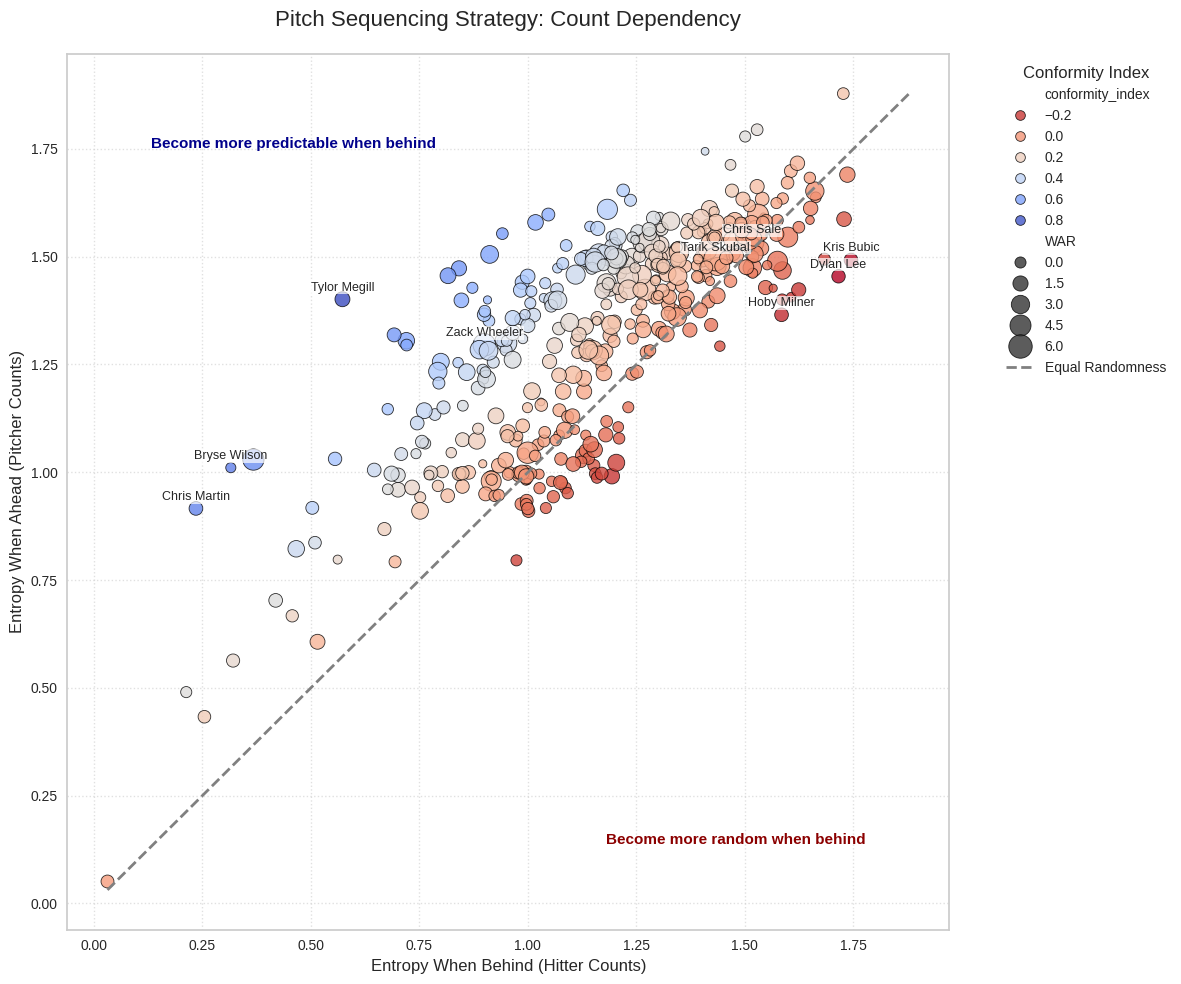


--- Top 'Pitching Backwards' Candidates (Negative Index) ---
                Name  entropy_behind  entropy_ahead  conformity_index
315        Dylan Lee        1.715643       1.454488         -0.261155
247       Kris Bubic        1.744391       1.492187         -0.252205
57       Hoby Milner        1.584353       1.365287         -0.219067
218     Tanner Scott        1.193471       0.990743         -0.202728
191  Mark Leiter Jr.        1.623924       1.423098         -0.200826


In [ ]:

comparison_df = comparison_df.reset_index().rename(columns={'pitcher': 'key_mlbam'})

# Merge with our clean pitcher data using 'final_pitcher_data' instead of 'final_features'
plot_data = comparison_df.merge(
    final_pitcher_data[['key_mlbam', 'Name', 'WAR', 'Team']],
    on='key_mlbam',
    how='inner' # Inner join ensures we only plot pitchers we have full data for
)

# --- 4. Create the Visualization ---
plt.figure(figsize=(12, 10))

scatter = sns.scatterplot(
    data=plot_data,
    x='entropy_behind',
    y='entropy_ahead',
    size='WAR',
    sizes=(20, 300),
    hue='conformity_index',
    palette='coolwarm_r', # Red = Backwards, Blue = Standard
    alpha=0.8,
    edgecolor='black'
)

# --- 5. Add Reference Elements ---
# Add Diagonal Line (x=y)
limit_min = min(plot_data['entropy_behind'].min(), plot_data['entropy_ahead'].min())
limit_max = max(plot_data['entropy_behind'].max(), plot_data['entropy_ahead'].max())
plt.plot([limit_min, limit_max], [limit_min, limit_max], color='gray', linestyle='--', linewidth=2, label='Equal Randomness')

# Add Text Labels
plt.text(limit_min + 0.1, limit_max - 0.1,
         "Become more predictable when behind",
         fontsize=11, color='darkblue', ha='left', va='top', weight='bold')

plt.text(limit_max - 0.1, limit_min + 0.1,
         "Become more random when behind",
         fontsize=11, color='darkred', ha='right', va='bottom', weight='bold')

# Label outliers
top_standard = plot_data.nlargest(3, 'conformity_index')
top_backwards = plot_data.nsmallest(3, 'conformity_index')
high_war = plot_data.nlargest(3, 'WAR')

for i, row in pd.concat([top_standard, top_backwards, high_war]).drop_duplicates().iterrows():
    plt.text(row['entropy_behind'], row['entropy_ahead'] + 0.02,
             row['Name'], fontsize=9, ha='center',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))

plt.title('Pitch Sequencing Strategy: Count Dependency', fontsize=16, pad=20)
plt.xlabel('Entropy When Behind (Hitter Counts)', fontsize=12)
plt.ylabel('Entropy When Ahead (Pitcher Counts)', fontsize=12)
plt.legend(title='Conformity Index', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Output leaders
print("\n--- Top 'Pitching Backwards' Candidates (Negative Index) ---")
print(plot_data.sort_values('conformity_index').head(5)[['Name', 'entropy_behind', 'entropy_ahead', 'conformity_index']])

#### Side note: who is the pitcher with like 0 entropy (bottom left corner)



In [ ]:
# Find player who has the lowest entropy when behind
lowest_entropy_behind_player = plot_data.loc[plot_data['entropy_behind'].idxmin()]
print(lowest_entropy_behind_player[['Name', 'entropy_behind']])

# Find player who has lowest entropy when ahead
lowest_entropy_ahead_player = plot_data.loc[plot_data['entropy_ahead'].idxmin()]
print(lowest_entropy_ahead_player[['Name', 'entropy_ahead']])

Name              Jose Alvarado
entropy_behind          0.03143
Name: 138, dtype: object
Name             Jose Alvarado
entropy_ahead         0.050961
Name: 138, dtype: object


This is [Jode Alvarado](https://baseballsavant.mlb.com/savant-player/jose-alvarado-621237?stats=statcast-r-pitching-mlb). He is a lefty reliever who just throws two different kinds of fastballs really, really fast.

### Graph Analysis

The fact that there are so many pitchers with a negative index is a bit surprising. According to what was done with the data, these pitchers mix it up more when they are behind, and less when they are ahead.

I hypothesize that this is because these low-score pitchers are two groups: Either
1. Relievers with a single dominant put-away, strikeout pitch,
2. Craftier pitchers who can't afford to be predictable in hitter's counts.

## Q2B: Do Pitchers who mix it up more in Hitters counts perform better?

Ie, are pitchers who are more backwards perform better?

In [ ]:
# --- 1. Merge Entropy Data with Advanced Features ---

# First, ensure comparison_df has the merging key (in case the previous viz block wasn't run)
if 'key_mlbam' not in comparison_df.columns:
    comparison_df = comparison_df.reset_index().rename(columns={'pitcher': 'key_mlbam'})

# Merge with 'final_pitcher_data' (the new cleaned dataframe) instead of 'final_features'
full_analysis = comparison_df.merge(
    final_pitcher_data[['key_mlbam', 'Name', 'Team', 'WAR', 'ERA', 'Stuff+', 'Location+']],
    on='key_mlbam',
    how='inner'
)

# --- 2. Correlation Matrix ---
# Let's see the raw relationships
correlations = full_analysis[['conformity_index', 'Stuff+', 'Location+', 'ERA', 'WAR']].corr()

print("--- Correlation with Conformity Index ---")
print(correlations['conformity_index'].sort_values(ascending=False))



--- Correlation with Conformity Index ---
conformity_index    1.000000
WAR                 0.088965
ERA                 0.031453
Location+           0.005943
Stuff+             -0.023005
Name: conformity_index, dtype: float64


So, pitchers who are more traditional (more positive conformity index) have a larger WAR and slightly above average Location+.

Pitchers who are more tricky when behind have better Stuff+ and better ERA.

I take it to mean this:
- If a pitcher has good Stuff+ (ball has alot of movement or is really fast or is really sneaky etc), they can be predictable and still effective. For example, if a pitcher is hurling 100mph fastballs or super nasty curveballs, even a hitter who knows it is coming can have a hard time.

**Another intersting note, pointed out by Sean:**

In Q0, we saw that backwards pitching is more effective then traditional. But here, traditional pitchers are positvely correlated with a higher WAR, which means a better pitcher. Why is this?

We belive that this is because these two questions are measuring different things.

Q0 is saying that throwing a breaking ball in a fastball count is a highly effective strategy.

But here, Q3 says that the players who rely on a Fastball foundation (A more traditionalist) tend to be the Starters who accumulate the most value (WAR)

But, players who break the mold and throw those breaking balls have a better ERA.

# Q3: Case Study: An Example Backwards Pitcher




## Example Backwards Pitcher

The above analysis gave [Dylan Lee](https://baseballsavant.mlb.com/savant-player/dylan-lee-669276) to be the most 'backwards' pitcher. So, we'll look at his stats and see if they may give a suggestion of why he becomes *more* predictable when behind in the count.

If you click the above link, you will notice Lee's really good breaking ball run value and offspeed run value.

Also note his pretty poor fastball run value / fastball velocity.

This means that Lee's fastball isn't too great, so he relies on backwards pitching a whole lot, esp when he is *down* in the count.

When he is up in the count, he usually just throws his slider low and forces batters to try to hit it.

___

Here are two nice visualization that can help:

You have to put the last name in the search bar.

[Pitcher Arsenal](https://baseballsavant.mlb.com/visuals/pitch3d?player_id=608337#v=1&mainView=tracking&pov=umpire&hitterSide=all&marks=none&plays1=all&plays2=all&pitchColors=pitch_type&dualActive=false&summaryViewActive=true) (Hit the 'arsenal' slider at bottom left, look at the cool visualization on bottom-right)

[Picher Plinko](https://baseballsavant.mlb.com/visuals/pitch-plinko) (Related graphic, a bit simpler)



In [ ]:
# Ensure role_data is loaded (it should be from previous cells, but for robustness)
# if 'role_data' not in locals():
#     from pybaseball import pitching_stats
#     role_data = pitching_stats(2024, qual=1)[['IDfg', 'Name', 'G', 'GS']]

# Merge final_pitcher_data with role_data to get 'G' and 'GS' columns
# Use 'IDfg' which is common between final_pitcher_data and role_data
final_pitcher_data_with_roles = final_pitcher_data.merge(
    role_data[['IDfg', 'G', 'GS']],
    on='IDfg',
    how='left' # Use left merge to keep all pitchers from final_pitcher_data
)

# 1) Make sure we have a Role column (Starter vs Reliever)
# This check is now performed on the new DataFrame
if 'Role' not in final_pitcher_data_with_roles.columns:
    # Fill NaN 'G' and 'GS' for pitchers not in role_data if any
    # This might happen if 'qual=30' for final_pitcher_data was stricter than 'qual=1' for role_data
    final_pitcher_data_with_roles['G'] = final_pitcher_data_with_roles['G'].fillna(0)
    final_pitcher_data_with_roles['GS'] = final_pitcher_data_with_roles['GS'].fillna(0)

    # Ensure 'G' is not zero to prevent division by zero
    # Pitchers with 0 games played will be classified as Reliever by default here.
    final_pitcher_data_with_roles['Role'] = np.where(
        (final_pitcher_data_with_roles['G'] > 0) & (final_pitcher_data_with_roles['GS'] / final_pitcher_data_with_roles['G'] > 0.6),
        'Starter',
        'Reliever'
    )

# 2) Grab Dylan Lee's row using the DataFrame with roles
dylan_row = final_pitcher_data_with_roles[
    final_pitcher_data_with_roles['Name'].str.contains("Dylan Lee", case=False, na=False)
]

# Check if Dylan Lee is found before trying to access .iloc[0]
if not dylan_row.empty:
    dylan_row = dylan_row.iloc[0][['Stuff+', 'Location+', 'WAR', 'ERA']]
else:
    print("Dylan Lee not found in the dataset.")
    dylan_row = pd.Series(dtype='float64') # Create an empty Series to avoid further errors

# 3) Compute average reliever stats using the DataFrame with roles
relief_avg = final_pitcher_data_with_roles[
    final_pitcher_data_with_roles['Role'] == 'Reliever'
][['Stuff+', 'Location+', 'WAR', 'ERA']].mean()

# 4) Side-by-side comparison
comparison = pd.DataFrame({
    'Dylan Lee': dylan_row,
    'Avg Reliever': relief_avg
})

print(comparison)


          Dylan Lee  Avg Reliever
Stuff+          105    103.673077
Location+       102     98.992308
WAR             0.8      0.458462
ERA            2.11      3.852808


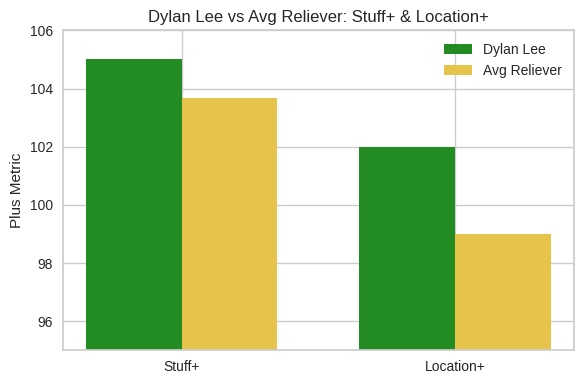

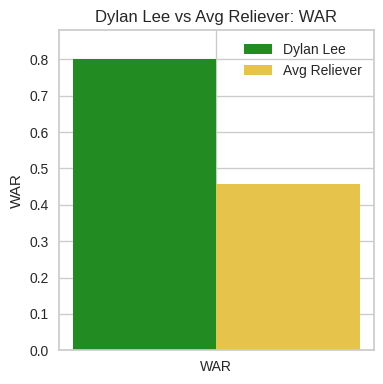

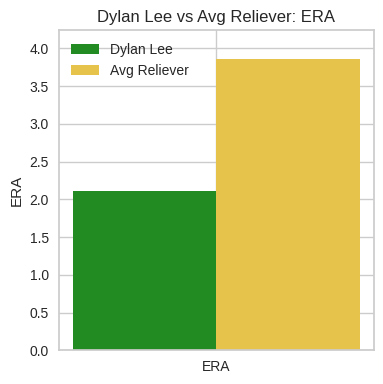

In [ ]:
import matplotlib.pyplot as plt
# --------------- Chart 1: Stuff+ and Location+ (y-min at 100) ---------------
metrics_sl = ['Stuff+', 'Location+']
plot_sl = comparison.loc[metrics_sl]

x = np.arange(len(metrics_sl))
width = 0.35
dylan_color ='#228B22'
relief_color = '#E6C34A'
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, plot_sl['Dylan Lee'], width, label='Dylan Lee', color=dylan_color)
ax.bar(x + width/2, plot_sl['Avg Reliever'], width, label='Avg Reliever', color=relief_color)

ax.set_xticks(x)
ax.set_xticklabels(metrics_sl)
ax.set_ylabel('Plus Metric')
ax.set_title('Dylan Lee vs Avg Reliever: Stuff+ & Location+')

# y-axis minimum at 95
y_min = 95
y_max = 106
ax.set_ylim(y_min, y_max)

ax.legend()
plt.tight_layout()
plt.show()

# --------------- Chart 2: WAR ---------------
metric_war = 'WAR'
plot_war = comparison.loc[[metric_war]]

x = np.arange(1)  # just one metric
width = 0.35

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(x - width/2, plot_war['Dylan Lee'], width, label='Dylan Lee', color=dylan_color)
ax.bar(x + width/2, plot_war['Avg Reliever'], width, label='Avg Reliever', color=relief_color)

ax.set_xticks(x)
ax.set_xticklabels([metric_war])
ax.set_ylabel('WAR')
ax.set_title('Dylan Lee vs Avg Reliever: WAR')

y_min = 0
y_max = max(plot_war.values.max(), 0) * 1.1 if plot_war.values.max() > 0 else 1
ax.set_ylim(y_min, y_max)

ax.legend()
plt.tight_layout()
plt.show()

# --------------- Chart 3: ERA ---------------
metric_era = 'ERA'
plot_era = comparison.loc[[metric_era]]

x = np.arange(1)  # just one metric
width = 0.35

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(x - width/2, plot_era['Dylan Lee'], width, label='Dylan Lee', color=dylan_color)
ax.bar(x + width/2, plot_era['Avg Reliever'], width, label='Avg Reliever', color=relief_color)

ax.set_xticks(x)
ax.set_xticklabels([metric_era])
ax.set_ylabel('ERA')
ax.set_title('Dylan Lee vs Avg Reliever: ERA')

y_min = 0
y_max = max(plot_era.values.max(), 0) * 1.1 if plot_era.values.max() > 0 else 1
ax.set_ylim(y_min, y_max)

ax.legend()
plt.tight_layout()
plt.show()


For a player like Lee who has a weaker fastball, his style relies on heavy usage of breaking and offspeed balls, which is why he is used as a relief pitcher.

If you throw backwards pitches more often than you don’t, at some point a fastball will become your new “backwards pitch."

It’s important as a pitcher to be multi-dimensional, being willing to throw a curveball without becoming reliant on it.


# Takeaways

## The Difficulty of Analyzing Backwards Pitching / Pitch Sequencing


Some common issues with doing pitch sequencing analyis are:

1. Sample Size Issues
    - If we want to account for many variables (inning, score, pitcher, count, etc), we have to rapidly shrink the sample size
    - We commonly have to aggregate pitches (ie, group all fastballs) to account for all combinations of pitch sequences.
2. Intent vs Execution
    - We have no way of telling if a good pitch is an accident or result of purposeful intent.
    - If a fastball is working against a certain batter, a pitcher will keep throwing it. The pitcher isn't even considering the sequence.
3. Many Variables; the Context
    - A pitch is a result of: velocty, movement, spin, release point, location, sequencing
    - Isolating sequencing is a huge simplification
    - Different hitters are pitched to differently


## Thoughts on this project

Overall, this is good info for the casual fan, or those looking to understand why the phrase 'backwards pitching' comes up during broadcasts.

But, none of this info would be suprising or novel for players or dedicated saber-metricians.


___

Another takeaway, more related to the field of Data Mining, is the issue of correlated varaibles and really the complexity of real world data (ie, Baseball games).


There is no on-off switch for backwards pitching; it depends on a million things: The pitcher, how the pitcher is feeling that day, the hitter being faced, score of the game, runners, fielder position, etc.

___

Failed Anaylsis:

Data mining or data science is an iterative process; we make hypothesis, test them, then update our hypothesis.

For example, the clustering of pitchers above failed due to flawed assumptions about how baseball is played. We didn't understand how these assumptions were flawed until the tests failed.

Additionally, a research direction we attempted in this project was to do sequencing mining (Like Word2Vec) on Pitch Sequences. But, ultimately, this direction never gave any meaningful results that we felt could be included in the project presentation (which is only 5 minutes long).

Some notes on this are below:



> But, as is obvious on later reflection, the strongest signal in what a pitcher is going to pitch is the count. As in, our model just learned the rules of baseball, not the kinds of pitches being thrown or the location of their throwing. Throw in the many noises of a baseball game, and these final embeddings were fairly meaningless. (Honestly, baseball is a pretty discrete sport. Doing this project on a more ?intermixed? game like football seems daunting, if not impossible)






## Final note on Yamamoto

Yamamoto is great because he throws his full arsenal (fastball + breaking + offspeed) all the time, leaving hitters guessing most of the time. He is so good with all of his pitches that doesn't really become 'more' or 'less' backwards depending on the count.

In [ ]:
yama_id_row = final_pitcher_data[final_pitcher_data['Name'] == 'Yoshinobu Yamamoto']

yama_id = yama_id_row['key_mlbam'].values[0]

yama_pitches = league_data_2024[
    (league_data_2024['pitcher'] == yama_id) &
    (league_data_2024['count_group'].isin(['Behind', 'Ahead']))
]

yama_usage = yama_pitches.groupby(['count_group', 'pitch_group']).size().unstack(fill_value=0)
yama_pcts = yama_usage.div(yama_usage.sum(axis=1), axis=0) * 100

print("--- Yoshinobu Yamamoto: Pitch Usage by Count State ---")
print(yama_pcts.round(1).astype(str) + '%')


Even though he throws his fastball more often in hitters counts, hitters still have to worry about his offspeed / breaking (Thrown 40% of the time). Note that he can do this pitch mix all of the time because of his great control over where the ball is thrown (ie, he doesn't walk anyone).



## Future Work

If we had more time, future analaysis could use some of the newer data captured by MLB. Spin rate, spin direction, pitch location, etc are all now available to casual fans online through Statcast.

Or, it could look at 'backwards pitching' from a batter's perspective, maybe looking at how a batter changes their swing based on the count. After all, swing data is now newly released and also avaialble online
